# Semana 9. ¿Qué tan popular será una canción nueva?

Data Analytics | Semana 9: Regresión y lectura crítica de IA | 2026-2

**Integrantes:** Santiago Villamil, María Salgado, Sofía Carrero y Paula Ortiz.

**Contexto.** Una disquera debe decidir, antes del lanzamiento, en qué canciones invierte promoción. El modelo estima la **popularidad** en una escala del 0 al 100 de una canción con las características que ya se conocen antes de lanzarla.

## Pregunta central

> ¿Se puede estimar la popularidad de una canción nueva usando solo lo que se sabe antes de lanzarla y, si se puede, con cuánta confianza puede la disquera usar ese número para decidir en qué canciones invertir promoción?


## 1. Preparar los datos

Estructura de carpetas esperada:

```text
IA-Predictiva-de-Canciones/
├── data/
│   └── canciones.csv
└── semana_09/
    └── analisis_regresion_equipo.ipynb
```

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, train_test_split
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

DATA_FILE = Path("../data/canciones.csv")

if not DATA_FILE.exists():
    raise FileNotFoundError("No se encontró data/canciones.csv. Ejecute el notebook desde la carpeta semana_09.")

df = pd.read_csv(DATA_FILE).sort_values("anio", kind="stable").reset_index(drop=True)

print("Archivo:", DATA_FILE.name)
print("Filas:", f"{len(df):,}")
print("Columnas:", df.shape[1])
df.head()

Archivo: canciones.csv
Filas: 2,000
Columnas: 13


,bailabilidad,energia,valencia,acustica,tempo,duracion_min,volumen_db,anio,colaboracion,genero,reproducciones_sem1,popularidad,es_hit
0,0.376,0.648,0.425,0.119,96.1,2.20,-4.0,1995,0,indie,426829,60.2,0
1,0.828,0.824,0.377,0.154,109.2,2.68,-6.5,1995,1,indie,534264,66.1,0
2,0.189,0.761,0.300,0.373,200.0,4.39,-12.2,1995,0,urbano,256039,46.3,0
3,0.845,0.559,0.759,0.084,149.3,2.43,-6.3,1995,0,pop,561896,67.9,0
4,0.429,0.893,0.419,0.441,134.3,5.23,-8.8,1995,0,electronica,459289,63.6,0


### Partición temporal

La disquera usará el modelo para canciones **futuras**. Por eso se entrena con el pasado (1995-2019) y se evalúa con el futuro (2020-2025). La parte de prueba **no se mira** hasta la evaluación.

In [2]:
ANIO_CORTE = 2020

train = df[df["anio"] < ANIO_CORTE].copy()
test = df[df["anio"] >= ANIO_CORTE].copy()

print("Entrenamiento:", len(train), "canciones,", train["anio"].min(), "-", train["anio"].max())
print("Prueba       :", len(test), "canciones,", test["anio"].min(), "-", test["anio"].max())

Entrenamiento: 1585 canciones, 1995 - 2019
Prueba       : 415 canciones, 2020 - 2025


### ¿Los datos sirven para aprender?

1. ¿Qué representa una fila, qué variable se predice y en qué escala está?
* RTA: Cada fila representa una canción (2.000 canciones), que cuenta con las variables bailabilidad, energía, valencia, acústica, tempo, duración, volumen, el año, el género y si hubo colaboración. La variable a predecir es la de popularidad en la escala de 0-100.
2. ¿Por qué se entrena con 1995-2019 y se prueba con 2020-2025 en vez de separar las canciones al azar?
* RTA: Se realizó una partición temporal tal que de 1995 - 2019 se descubrieran patrones de ritmo, género, acústica en las canciones que fueron exitosas y del 2020 - 2025 se aplican los patrones encontrados ya sabiendo que canciones fueron populares pero desconocidas para el modelo y así rectificar que en un futuro su uso funcione. Por otro lado no se hace al azar porque la información antigua y nueva en el entrenamiento se mezclaría generando fuga de datos.

## 2. Explorar sin mirar la prueba

Toda la exploración usa **solo `train`** el conjunto de prueba de 1995-2019. Si se mirara la prueba para decidir qué hacer con los datos, la evaluación final dejaría de ser honesta.


In [3]:
display(train.describe().T.round(2))
print("Canciones por género:")
display(train["genero"].value_counts())

,count,mean,std,min,25%,50%,75%,max
bailabilidad,1585.0,0.52,0.22,0.03,0.36,0.53,0.69,0.99
energia,1585.0,0.57,0.21,0.03,0.42,0.58,0.73,1.00
valencia,1585.0,0.49,0.23,0.02,0.32,0.50,0.68,0.96
acustica,1585.0,0.34,0.20,0.00,0.18,0.32,0.48,0.94
tempo,1585.0,119.99,24.80,60.00,103.20,119.10,135.70,200.00
duracion_min,1585.0,3.50,0.81,1.50,2.96,3.50,4.05,6.15
volumen_db,1585.0,-8.00,3.02,-18.80,-10.00,-8.00,-6.00,0.00
anio,1585.0,2007.30,7.20,1995.00,2001.00,2007.00,2014.00,2019.00
colaboracion,1585.0,0.25,0.43,0.00,0.00,0.00,1.00,1.00
reproducciones_sem1,1585.0,421317.52,178424.77,18475.00,289851.00,406438.00,537617.00,1121386.00


Canciones por género:


genero
pop            488
urbano         413
rock           266
electronica    220
indie          198
Name: count, dtype: int64

### Calidad de los datos: nulos y duplicados

In [4]:
calidad = pd.DataFrame({
    "faltantes": train.isna().sum(),
    "porcentaje_faltante": (train.isna().mean() * 100).round(1),
    "valores_unicos": train.nunique(),
})
display(calidad)
print("Filas duplicadas:", int(train.duplicated().sum()))

,faltantes,porcentaje_faltante,valores_unicos
bailabilidad,0,0.0,700
energia,0,0.0,697
valencia,0,0.0,742
acustica,0,0.0,677
tempo,0,0.0,776
duracion_min,0,0.0,356
volumen_db,0,0.0,157
anio,0,0.0,25
colaboracion,0,0.0,2
genero,0,0.0,5


Filas duplicadas: 0


### Valores Extremos

In [5]:
numericas = train.drop(columns=["anio", "colaboracion", "es_hit"]).select_dtypes("number")

q1, q3 = numericas.quantile(0.25), numericas.quantile(0.75)
iqr = q3 - q1
extremos = ((numericas < q1 - 1.5 * iqr) | (numericas > q3 + 1.5 * iqr)).sum()

display(pd.DataFrame({"valores_extremos": extremos, "porcentaje": (extremos / len(train) * 100).round(1)}))

,valores_extremos,porcentaje
bailabilidad,0,0.0
energia,0,0.0
valencia,0,0.0
acustica,1,0.1
tempo,8,0.5
duracion_min,7,0.4
volumen_db,5,0.3
reproducciones_sem1,10,0.6
popularidad,10,0.6


### Correlaciones y redundancia

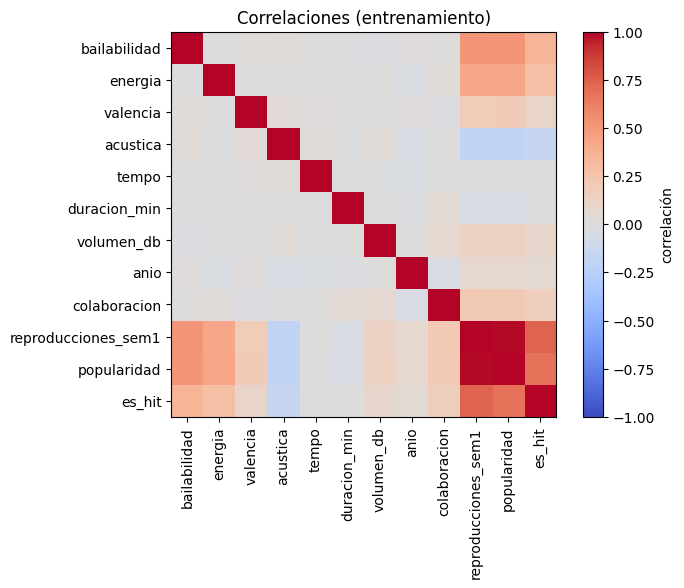

Correlación con la popularidad:


reproducciones_sem1    0.986
es_hit                 0.673
bailabilidad           0.517
energia                0.434
colaboracion           0.199
valencia               0.189
volumen_db             0.134
anio                   0.076
tempo                 -0.002
duracion_min          -0.048
acustica              -0.201
Name: popularidad, dtype: float64

Pares de variables con |correlación| > 0,7:


reproducciones_sem1  popularidad    0.986
                     es_hit         0.731
dtype: float64

In [6]:
corr = train.select_dtypes("number").corr()

plt.figure(figsize=(7, 5))
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.xticks(range(len(corr)), corr.columns, rotation=90)
plt.yticks(range(len(corr)), corr.columns)
plt.colorbar(label="correlación")
plt.title("Correlaciones (entrenamiento)")
plt.show()

print("Correlación con la popularidad:")
display(corr["popularidad"].drop("popularidad").sort_values(ascending=False).round(3))

pares = corr.where(np.triu(np.ones(corr.shape), 1).astype(bool)).stack()
print("Pares de variables con |correlación| > 0,7:")
display(pares[pares.abs() > 0.7].round(3))

### Decisiones de Preparación

**Decisión 1:** Respecto a los datos faltantes y duplicados no se encontraron registros en las columnas ni en las filas por lo que la información se manipula tal como viene.

**Decisión 2:** Los valores extremos representan menos del 1%, y esos datos extremos cobran coherencia por la variabilidad estructural natural de los datos como por ejemplo la duración, el tempo, etc. A lo anterior hay que tener en cuenta que si se eliminan las canciones con alta popularidad se perderían los éxitos que pide la disquera y el modelo se entrenaría bajo una popularidad más baja.

**Decisión 3:** Entre las características de la canción no hay variables muy correlacionadas entre sí (ningún par supera 0,5), así que se mantienen todas. Las únicas correlaciones altas son reproducciones_sem1 (0,986) y es_hit (0,673) con la popularidad. Eso no es redundancia, sino una señal de fuga de información, por lo que se dejan fuera del modelo. Si se incluyeran, el modelo parecería casi perfecto sin serlo y la disquera tomaría una decisión con una cifra engañosa.

## 3. El momento de la decisión

Una variable solo puede entrar al modelo si se conoce **antes del lanzamiento**, que es cuando la disquera decide. La tabla de control revisa cada columna contra ese momento.


In [7]:
pd.DataFrame({"tipo": df.dtypes.astype(str), "ejemplo": df.iloc[0]})

,tipo,ejemplo
bailabilidad,float64,0.376
energia,float64,0.648
valencia,float64,0.425
acustica,float64,0.119
tempo,float64,96.1
duracion_min,float64,2.2
volumen_db,float64,-4.0
anio,int64,1995
colaboracion,int64,0
genero,object,indie


### Tabla de control de variables

| Variable | ¿Se conoce antes del lanzamiento? | Entra | Justificación |
|---|---|---|---|
| bailabilidad, energia, valencia, acustica | Sí | Entra | Son características musicales que se miden en el estudio antes de publicar la canción y ayudan a saber si gustará. |
| tempo, volumen_db, anio, colaboracion | Sí | Entra | Son datos técnicos y detalles de la producción que ya están definidos antes del estreno. |
| duracion_min | Sí | Entra | La duración exacta de la canción se conoce desde que se termina de grabar el audio final. |
| genero | Sí | Entra | El género musical está definido y conocido mucho antes de lanzar la canción al mercado. |
| reproducciones_sem1 | No | Fuera | Ocurre días después del estreno; usarlo sería hacer trampa usando datos del futuro. |
| es_hit | No | Fuera | Es una etiqueta que solo se sabe cuando la canción ya tuvo éxito comercial. |
| popularidad | No | Fuera | Es la nota o resultado final que queremos adivinar (la meta del modelo), no una variable de entrada. |

## 4. Cuando un modelo parece demasiado bueno

Se entrena el mismo modelo lineal dos veces sobre la misma partición temporal: una con todas las columnas y otra solo con las columnas válidas. Lo único que cambia es la presencia de las dos columnas sospechosas.

In [8]:
columnas_num = ["bailabilidad", "energia", "valencia", "acustica", "tempo","duracion_min", "volumen_db", "anio", "colaboracion"]
columnas_validas = columnas_num + ["genero"]
fuga = ["reproducciones_sem1", "es_hit"]

y_train = train["popularidad"]
y_test = test["popularidad"]

def agregar_derivadas(X):
    X = X.copy()
    X["duracion_c2"] = (X["duracion_min"] - 3.5) ** 2
    X["valencia_acustica"] = X["valencia"] * X["acustica"]
    X["colab_indie"] = (X["colaboracion"] * (X["genero"] == "indie")).astype(float)
    X["pop_energia"] = (X["genero"] == "pop") * X["energia"]
    X["pop_bailabilidad"] = (X["genero"] == "pop") * X["bailabilidad"]
    X["urbano_bailabilidad"] = (X["genero"] == "urbano") * X["bailabilidad"]
    return X

def armar_modelo(estimador, numericas, con_derivadas=False):
    pre = ColumnTransformer([
        ("genero", OneHotEncoder(handle_unknown="ignore", sparse_output=False), ["genero"]),
        ("num", StandardScaler(), numericas),
    ])
    pasos = [("pre", pre), ("modelo", estimador)]
    if con_derivadas:
        pasos.insert(0, ("derivadas", FunctionTransformer(agregar_derivadas)))
    return Pipeline(pasos)

def metricas(real, esperado):
    return {
        "MAE": mean_absolute_error(real, esperado),
        "RMSE": mean_squared_error(real, esperado) ** 0.5,
        "R2": r2_score(real, esperado),
        "sesgo": float((real - esperado).mean()), 
    }

print("Correlación de las columnas sospechosas con la popularidad (entrenamiento):")
display(train[fuga + ["popularidad"]].corr()["popularidad"].drop("popularidad").round(3))

Correlación de las columnas sospechosas con la popularidad (entrenamiento):


reproducciones_sem1    0.986
es_hit                 0.673
Name: popularidad, dtype: float64

In [9]:
con_fuga = armar_modelo(LinearRegression(), columnas_num + fuga).fit(train[columnas_validas + fuga], y_train)
sin_fuga = armar_modelo(LinearRegression(), columnas_num).fit(train[columnas_validas], y_train)

pred_con = con_fuga.predict(test[columnas_validas + fuga])
pred_sin = sin_fuga.predict(test[columnas_validas])

pd.DataFrame({"con las dos columnas": metricas(y_test, pred_con),"sin las dos columnas": metricas(y_test, pred_sin)}).round(3)
print("MAE = Error absoluto medio \nRMSE = Raíz del error cuadrático medio \nR2 = Coeficiente de determinación \nsesgo = Promedio de los errores (real - esperado)")

MAE = Error absoluto medio 
RMSE = Raíz del error cuadrático medio 
R2 = Coeficiente de determinación 
sesgo = Promedio de los errores (real - esperado)


### ¿Adivinar el pasado o estimar el futuro?

1. ¿Qué le pasa al MAE y al R² al retirar `reproducciones_sem1` y `es_hit`, y por qué esas dos columnas no existen el día en que la disquera decide?
* Al retirar las dos columnas, el MAE sube de 1,41 a 5,87 puntos. La primera cifra muestra variables que miden eventos posteriores al estreno y causan fuga de datos (data leakage). Muestran un modelo que lee un resultado ya ocurrido, no lo que ocurriría a futuro.
2. ¿cuál pondría: el de "con las dos columnas" o el de "sin las dos columnas"? ¿Por qué?
* La opción sin las dos columnas, un MAE de unos 5,9 puntos. Es el único que corresponde a la información que de verdad se tiene antes del lanzamiento, y por eso es el error que la disquera puede esperar en la práctica.

## 5. Separar el pasado del futuro

Se compara una partición al azar con la partición temporal usando el mismo modelo y las mismas columnas válidas.

In [10]:
X_ini, X_fin, y_ini, y_fin = train_test_split(
    df[columnas_validas], df["popularidad"], test_size=0.2, random_state=42)

al_azar = armar_modelo(LinearRegression(), columnas_num).fit(X_ini, y_ini)

pd.DataFrame({
    "partición al azar 80/20": metricas(y_fin, al_azar.predict(X_fin)),
    "partición temporal": metricas(y_test, pred_sin),
}).round(3)

,partición al azar 80/20,partición temporal
MAE,6.157,5.872
RMSE,7.741,7.363
R2,0.690,0.701
sesgo,-0.200,0.306


### ¿El resultado se sostiene hacia el futuro?

1. ¿Cambia mucho el resultado entre la partición al azar y la temporal en estos datos?
* El resultado no cambia mucho. Las métricas son bastante similares en ambos casos. Por ejemplo, el MAE pasa de 6,157 (al azar) a 5,872 (temporal), y el R² sube ligeramente de 0,690 a 0,701. 
2. Aunque no cambie mucho, ¿por qué sigue siendo más correcto evaluar con la partición temporal?
* Sigue siendo más correcto porque simula fielmente el escenario real de uso. La disquera tomará decisiones sobre canciones futuras basándose en datos pasados.

## 6. Línea base y registro

Una línea base es la estimación más simple posible. Aquí se usa **la popularidad media de cada género** en el entrenamiento.

Toda corrida se anota en el registro comparativo, **incluidas las que se descartan**, con su forma de validación y sus métricas.

In [11]:
registro = []

def anotar(corrida, validacion, esperado, nota=""):
    fila = {"corrida": corrida, "validacion": validacion}
    fila.update({k: round(v, 3) for k, v in metricas(y_test, esperado).items()})
    fila["nota"] = nota
    registro.append(fila)

VALIDACION = "entrena 1995-2019, prueba 2020-2025"

media_genero = train.groupby("genero")["popularidad"].mean()
base = test["genero"].map(media_genero)

anotar("línea base: media por género", VALIDACION, base, "referencia")
anotar("lineal, todas las columnas", VALIDACION, pred_con, "descartada: usa columnas con fuga")
anotar("lineal, columnas válidas", VALIDACION, pred_sin)

pd.DataFrame(registro)

,corrida,validacion,MAE,RMSE,R2,sesgo,nota
0,línea base: media por género,"entrena 1995-2019, prueba 2020-2025",10.443,13.155,0.047,2.924,referencia
1,"lineal, todas las columnas","entrena 1995-2019, prueba 2020-2025",1.406,1.968,0.979,0.117,descartada: usa columnas con fuga
2,"lineal, columnas válidas","entrena 1995-2019, prueba 2020-2025",5.872,7.363,0.701,0.306,


## 7. Modelado

Se comparan tres algoritmos con las mismas columnas válidas, la misma partición y las mismas métricas, entonces:  ¿Qué algoritmo estima mejor la popularidad?

### Los tres algoritmos en palabras simples

* **Regresión lineal:** ajusta una fórmula que suma el aporte de cada variable (por ejemplo, más bailabilidad, más popularidad). Es simple y fácil de interpretar.
* **Gradient boosting:** construye muchos árboles de decisión pequeños, uno después de otro, y cada árbol nuevo intenta corregir los errores de los anteriores.
* **Random forest:** construye muchos árboles de decisión a la vez, cada uno con una parte distinta de los datos, y promedia sus respuestas.

Un árbol de decisión hace preguntas del tipo "¿la bailabilidad es mayor que 0,6?" y termina en un valor. Los modelos de árboles capturan relaciones complejas, pero **solo devuelven valores parecidos a los que vieron al entrenar**. Para comparar los tres se usa la tabla del registro que aparece al ejecutar la celda siguiente (columnas MAE y sesgo).

In [12]:
algoritmos = {
    "lineal": LinearRegression(),
    "gradient boosting": GradientBoostingRegressor(random_state=42),
    "random forest": RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
}

for nombre, estimador in algoritmos.items():
    if nombre == "lineal":
        continue   # ya está en el registro como "lineal, columnas válidas"
    modelo = armar_modelo(estimador, columnas_num).fit(train[columnas_validas], y_train)
    anotar(nombre + ", columnas válidas", VALIDACION, modelo.predict(test[columnas_validas]))

pd.DataFrame(registro)

,corrida,validacion,MAE,RMSE,R2,sesgo,nota
0,línea base: media por género,"entrena 1995-2019, prueba 2020-2025",10.443,13.155,0.047,2.924,referencia
1,"lineal, todas las columnas","entrena 1995-2019, prueba 2020-2025",1.406,1.968,0.979,0.117,descartada: usa columnas con fuga
2,"lineal, columnas válidas","entrena 1995-2019, prueba 2020-2025",5.872,7.363,0.701,0.306,
3,"gradient boosting, columnas válidas","entrena 1995-2019, prueba 2020-2025",6.590,8.117,0.637,2.004,
4,"random forest, columnas válidas","entrena 1995-2019, prueba 2020-2025",7.015,8.772,0.576,1.957,


In [13]:
print("Popularidad promedio en entrenamiento (1995-2019):", round(y_train.mean(), 1))
print("Popularidad promedio en prueba (2020-2025):      ", round(y_test.mean(), 1))

Popularidad promedio en entrenamiento (1995-2019): 57.9
Popularidad promedio en prueba (2020-2025):       60.8


### ¿Qué algoritmo estima mejor?

Use la tabla del registro de arriba y las dos cifras de popularidad promedio.

1. ¿Qué algoritmo tiene el menor MAE y cuánto reduce el error frente a la línea base?
* RTA: En la tabla del registro, la regresión lineal tiene el menor MAE (5,87), frente a gradient boosting (6,59) y random forest (7,02). La línea base tiene un MAE de 10,44, así que la regresión lineal reduce el error en un 44 %, casi a la mitad.
2. Los dos algoritmos de árboles tienen un sesgo cercano a +2 y la regresión lineal de solo +0,3 (sesgo positivo: el modelo se queda corto). Mirando la popularidad promedio de entrenamiento y de prueba, ¿por qué cree que los árboles subestiman las canciones de 2020-2025?
* RTA: La popularidad promedio sube con el tiempo: 57,9 en entrenamiento (1995-2019) y 60,8 en prueba (2020-2025). Los árboles solo devuelven valores parecidos a los que vieron al entrenar, así que no siguen esa tendencia y se quedan cortos (sesgo cercano a +2). La regresión lineal sí puede extender la tendencia, y su sesgo es de solo +0,3.

## 8. Validar como se va a usar

Dentro del entrenamiento se usa una **ventana creciente**: cada pliegue ajusta el modelo con los años anteriores y lo valida con el bloque siguiente. Con esto se comparan modelos **sin tocar la prueba**. ¿La comparación entre algoritmos es estable en el tiempo?

In [14]:
def mae_por_pliegue(estimador, pliegues=3):
    X, y = train[columnas_validas], train["popularidad"]
    maes = []
    for i_ajuste, i_valida in TimeSeriesSplit(n_splits=pliegues).split(X):
        modelo = armar_modelo(estimador, columnas_num).fit(X.iloc[i_ajuste], y.iloc[i_ajuste])
        maes.append(mean_absolute_error(y.iloc[i_valida], modelo.predict(X.iloc[i_valida])))
    return maes

ventana = pd.DataFrame({nombre: mae_por_pliegue(est) for nombre, est in algoritmos.items()},
                       index=["pliegue 1", "pliegue 2", "pliegue 3"])
ventana.loc["promedio"] = ventana.mean()
ventana.round(2)

,lineal,gradient boosting,random forest
pliegue 1,6.46,7.04,7.65
pliegue 2,6.26,7.17,7.54
pliegue 3,6.09,6.43,6.77
promedio,6.27,6.88,7.32


### ¿La comparación es estable en el tiempo?

1. ¿El orden de los algoritmos en la validación interna coincide con el de la prueba 2020-2025?
* Sí. En la ventana creciente el orden es lineal (6,27), gradient boosting (6,88) y random forest (7,32), igual que en la prueba 2020-2025.
2. ¿Por qué la prueba final se reserva para el final y no se usa para elegir el modelo?
* Si los usamos para decidir, contaminamos la prueba: el modelo se ajustará a ese grupo específico y dará un error falso, mucho mejor del que tendrá en la práctica.

## 9. Regresión: leer las métricas

Cuatro métricas, cuatro preguntas distintas:

* **MAE:** error promedio, en puntos de popularidad.
* **RMSE:** como el MAE, pero penaliza más los errores grandes.
* **R²:** fracción de la variación que el modelo explica. No es un porcentaje de aciertos.
* **Sesgo:** promedio de (real − esperado). Positivo significa que el modelo se queda corto.

**Aporta a la pregunta central:** ¿Cuántos puntos de popularidad se equivoca el modelo?

**Cómo leer la tabla de abajo.** Cada columna es un modelo y cada fila una métrica. «Línea base» es la regla simple (media por género) y «lineal, columnas válidas» es el modelo sin las columnas con fuga.

In [15]:
pd.DataFrame({
    "línea base": metricas(y_test, base),
    "lineal, columnas válidas": metricas(y_test, pred_sin),
}).round(3)

,línea base,"lineal, columnas válidas"
MAE,10.443,5.872
RMSE,13.155,7.363
R2,0.047,0.701
sesgo,2.924,0.306


### ¿Cuántos puntos se equivoca el modelo?

1. Con el MAE de la tabla: ¿cuántos puntos se equivoca en promedio la línea base y cuántos el modelo? ¿Cuántas veces es menor el error del modelo?
* RTA: La línea base, que solo usa la popularidad promedio de cada género, se equivoca en promedio 10,44 puntos. El modelo se equivoca 5,87 puntos. Es decir, el error del modelo es casi la mitad (unas 1,8 veces menor), así que las características de la canción aportan información que el género solo no tiene.
2. ¿Por qué el RMSE es mayor que el MAE y qué dice eso sobre los errores del modelo?
* RTA: El RMSE (7,36) castiga más los errores grandes y el MAE (5,87) los trata a todos igual. Que el RMSE sea mayor indica que hay algunas canciones donde el modelo se equivoca bastante más que el promedio.
3. ¿Qué significa un R² cercano a 0,7 y qué **no** significa?
* RTA: Significa que el modelo explica cerca del 70 % de las diferencias de popularidad entre canciones (R² = 0,701). No significa que acierte el 70 % de las canciones: el 30 % restante depende de cosas que el modelo no ve.

## 10. Feature engineering: Idea propia del equipo

Hasta aquí el modelo usa las columnas tal como vienen. Una variable derivada es una columna nueva que el equipo construye a partir de las existentes porque tiene una razón para pensar que ayuda.

La función `agregar_derivadas` (sección 4) crea seis variables, calculadas fila a fila:

* `duracion_c2`: duración centrada en 3,5 minutos y elevada al cuadrado.
* `valencia_acustica`, `colab_indie`, `pop_energia`, `pop_bailabilidad`, `urbano_bailabilidad`: interacciones.

Se agregan de a una familia y se anota cada corrida, también las que no mejoran.

In [16]:
derivadas_solo_duracion = ["duracion_c2"]
derivadas_equipo = ["duracion_c2", "valencia_acustica", "colab_indie",
                    "pop_energia", "pop_bailabilidad", "urbano_bailabilidad"]

candidatos = {
    "lineal + duración²": armar_modelo(LinearRegression(), columnas_num + derivadas_solo_duracion, con_derivadas=True),
    "lineal + variables derivadas del equipo": armar_modelo(LinearRegression(), columnas_num + derivadas_equipo, con_derivadas=True),
    "ridge + variables derivadas del equipo": armar_modelo(Ridge(alpha=1.0), columnas_num + derivadas_equipo, con_derivadas=True),
}

for nombre, modelo in candidatos.items():
    modelo.fit(train[columnas_validas], y_train)
    anotar(nombre, VALIDACION, modelo.predict(test[columnas_validas]))

registro_df = pd.DataFrame(registro)
registro_df

,corrida,validacion,MAE,RMSE,R2,sesgo,nota
0,línea base: media por género,"entrena 1995-2019, prueba 2020-2025",10.443,13.155,0.047,2.924,referencia
1,"lineal, todas las columnas","entrena 1995-2019, prueba 2020-2025",1.406,1.968,0.979,0.117,descartada: usa columnas con fuga
2,"lineal, columnas válidas","entrena 1995-2019, prueba 2020-2025",5.872,7.363,0.701,0.306,
3,"gradient boosting, columnas válidas","entrena 1995-2019, prueba 2020-2025",6.590,8.117,0.637,2.004,
4,"random forest, columnas válidas","entrena 1995-2019, prueba 2020-2025",7.015,8.772,0.576,1.957,
5,lineal + duración²,"entrena 1995-2019, prueba 2020-2025",5.754,7.151,0.718,0.264,
6,lineal + variables derivadas del equipo,"entrena 1995-2019, prueba 2020-2025",5.666,7.101,0.722,0.271,
7,ridge + variables derivadas del equipo,"entrena 1995-2019, prueba 2020-2025",5.671,7.106,0.722,0.268,


### Idea propia y el modelo elegido

1. ¿Qué variables derivadas propone el equipo y qué razón tiene para cada una?
* Duracion_c2 (la duración al cuadrado): las canciones muy cortas o muy largas pierden popularidad, y su coeficiente es negativo (−2,03). Las demás son interacciones, en las que el efecto de una característica depende del género: pop_energia, pop_bailabilidad, urbano_bailabilidad y colab_indie (colaboración en indie), más valencia_acustica, que mezcla el ánimo de la canción con la acústica.
2. ¿Cuánto mejora el MAE frente a "lineal, columnas válidas"? ¿Ridge mejora algo frente a la regresión lineal con las mismas variables? ¿De dónde viene entonces la mejora?
* El MAE baja de 5,87 a 5,67 (una mejora del 3,5%). Como Ridge (5,671) da prácticamente el mismo resultado que la regresión lineal (5,666), el avance proviene de las variables creadas y no del algoritmo.
3. ¿Qué modelo elige el equipo y por qué?
* El modelo elegido para producción es Ridge con variables derivadas: ofrece un rendimiento idéntico a la regresión lineal, un sesgo insignificante (0,27) y supera a todos los otros modelos y a la línea base.

In [17]:
# Modelo elegido por el equipo. Cámbielo si su registro favorece a otro.
modelo_final = candidatos["ridge + variables derivadas del equipo"]
pred_final = modelo_final.predict(test[columnas_validas])

registro_df.to_csv("registro_semana9.csv", index=False)
print("Registro guardado en semana_09/registro_semana9.csv con", len(registro_df), "corridas.")

Registro guardado en semana_09/registro_semana9.csv con 8 corridas.


## 11. El error no se reparte igual

Un promedio global puede esconder dónde falla el modelo. ¿Dónde falla el modelo y hacia dónde?

In [18]:
test_error = test[["genero"]].copy()
test_error["error"] = y_test - pred_final

por_genero = test_error.groupby("genero")["error"].agg(
    canciones="size",
    MAE=lambda e: e.abs().mean(),
    sesgo="mean",
).round(2)
display(por_genero)

dentro_de_10 = (test_error["error"].abs() <= 10).mean() * 100
print(f"Canciones a ±10 puntos de lo esperado: {dentro_de_10:.0f} %")

,canciones,MAE,sesgo
genero,,,
electronica,69,5.58,-0.01
indie,53,5.65,-0.90
pop,128,5.80,1.35
rock,67,5.09,-0.67
urbano,98,5.97,0.32


Canciones a ±10 puntos de lo esperado: 84 %


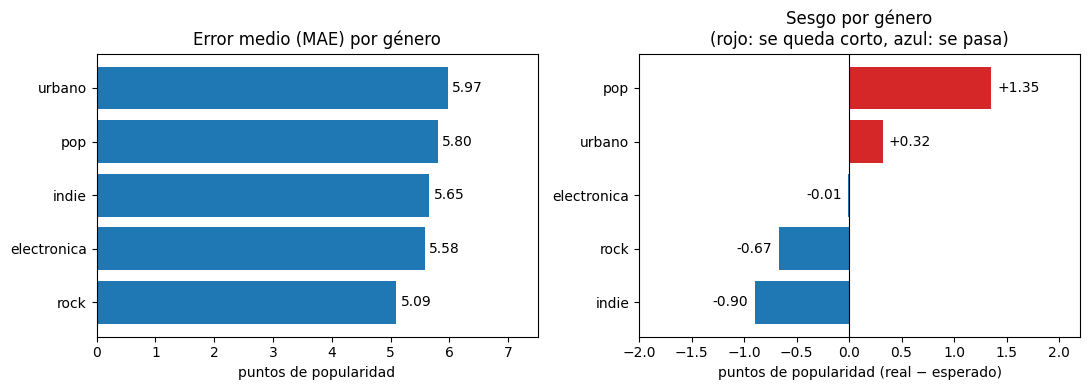

In [19]:
orden_mae = por_genero["MAE"].sort_values()
orden_sesgo = por_genero["sesgo"].sort_values()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.barh(orden_mae.index, orden_mae.values)
ax1.set_xlim(0, 7.5)
ax1.set_title("Error medio (MAE) por género")
ax1.set_xlabel("puntos de popularidad")
for i, v in enumerate(orden_mae.values):
    ax1.text(v + 0.08, i, f"{v:.2f}", va="center")

colores = ["tab:red" if v > 0 else "tab:blue" for v in orden_sesgo.values]
ax2.barh(orden_sesgo.index, orden_sesgo.values, color=colores)
ax2.axvline(0, color="black", linewidth=0.8)
ax2.set_xlim(-2, 2.2)
ax2.set_title("Sesgo por género\n(rojo: se queda corto, azul: se pasa)")
ax2.set_xlabel("puntos de popularidad (real − esperado)")
for i, v in enumerate(orden_sesgo.values):
    ax2.text(v + (0.06 if v >= 0 else -0.06), i, f"{v:+.2f}", va="center", ha="left" if v >= 0 else "right")

plt.tight_layout()
plt.show()

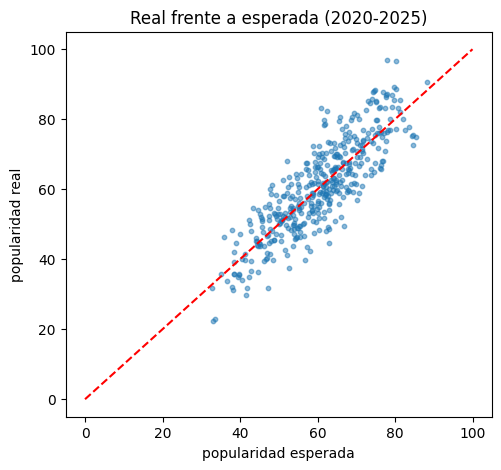

In [20]:
plt.figure(figsize=(5.5, 5))
plt.scatter(pred_final, y_test, s=10, alpha=0.5)
plt.plot([0, 100], [0, 100], "r--")
plt.xlabel("popularidad esperada")
plt.ylabel("popularidad real")
plt.title("Real frente a esperada (2020-2025)")
plt.show()

### ¿Dónde falla el modelo y hacia dónde?

1. Observe el primer gráfico (MAE por género): ¿en qué género es mayor el error y en cuál es menor?
* RTA: El error es mayor en urbano (5,97 puntos) y pop (5,80), y menor en rock (5,09). Las diferencias son pequeñas: ningún género se aleja mucho del error promedio.
2. Observe el segundo gráfico (sesgo por género): ¿en qué géneros el modelo se queda corto (barra roja) y en cuáles se pasa (barra azul)? ¿Cuál es el sesgo más grande?
* RTA: Se queda corto (barras rojas) en pop (+1,35) y urbano (+0,32). Se pasa (barras azules) en indie (−0,90), rock (−0,67) y, casi nada, en electrónica (−0,01). El sesgo más grande es el de pop (+1,35): sus canciones salen en promedio algo más populares de lo que el modelo estima.
3. ¿El modelo sirve para **pronosticar una canción** o para **priorizar un catálogo**? Justifique con el gráfico de real frente a esperada y el porcentaje de canciones a ±10 puntos.
* RTA: Sirve para priorizar un catálogo. El 84 % de las canciones queda a ±10 puntos de lo esperado, pero el 16 % se aleja más, como se ve en la dispersión alrededor de la diagonal. Por eso no sirve para afirmar cuánto sacará una canción puntual.

## 12. Importancia

La importancia por permutación baraja una variable en la prueba y mide cuánto empeora el MAE. Los coeficientes agregan la dirección del efecto, pero describen **asociaciones, no causas**.

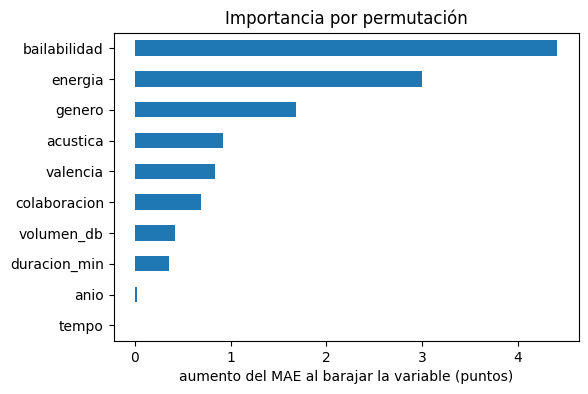

In [21]:
imp = permutation_importance(modelo_final, test[columnas_validas], y_test, n_repeats=20,
                             random_state=42, scoring="neg_mean_absolute_error")
importancia = pd.Series(imp.importances_mean, index=columnas_validas).sort_values()

plt.figure(figsize=(6, 4))
importancia.plot.barh()
plt.xlabel("aumento del MAE al barajar la variable (puntos)")
plt.title("Importancia por permutación")
plt.show()

In [22]:
nombres = modelo_final.named_steps["pre"].get_feature_names_out()
coeficientes = pd.Series(modelo_final.named_steps["modelo"].coef_, index=nombres)
coeficientes.sort_values().round(2)

genero__genero_indie         -5.99
genero__genero_rock          -3.17
num__acustica                -2.43
num__duracion_c2             -2.03
num__pop_energia             -1.05
num__duracion_min            -0.72
num__valencia_acustica       -0.59
num__pop_bailabilidad        -0.36
num__tempo                   -0.03
genero__genero_electronica    0.13
num__colab_indie              0.36
num__urbano_bailabilidad      0.72
num__anio                     1.17
num__volumen_db               1.64
num__colaboracion             2.45
num__valencia                 3.07
genero__genero_urbano         3.73
genero__genero_pop            5.30
num__energia                  6.25
num__bailabilidad             7.15
dtype: float64

### ¿Qué se asocia con la popularidad?

1. ¿Qué variables concentran la importancia? ¿Puede decirse que un coeficiente negativo en un género "causa" menor popularidad?
* La bailabilidad (aumenta el MAE 4,41 puntos al barajarla) y la energía (3,00) concentran la importancia, seguidas por el género (1,68). El año y el tempo casi no importan. Un coeficiente negativo, como el de indie (−5,99) indica asociación, no causa.
2. ¿Qué no sabe el modelo? (Piense en qué pasa fuera de 1995-2025 y en lo que no está en el archivo.)
* No ve la promoción, el artista, las listas de reproducción ni las redes sociales, solo características de la canción. Tampoco sabe qué pasará fuera de 1995-2025, porque los gustos cambian.

## 13. ¿Con qué corte se decide a quién promocionar?

Un modelo de regresión entrega un número. Para convertirlo en acción se necesita un **corte**: se promocionan las canciones cuya popularidad esperada lo supera. Cuanto más alto es el corte, menos canciones se promocionan.

La tabla de abajo usa las 415 canciones de 2020-2025. De ellas, 106 alcanzaron 70 puntos de popularidad real (los «éxitos»).

In [23]:
llegaron_a_70 = (y_test >= 70)
filas = []
for corte in [60, 65, 70]:
    promocionadas = pred_final >= corte
    filas.append({
        "corte": corte,
        "canciones promocionadas": int(promocionadas.sum()),
        "de ellas, alcanzaron 70": int((promocionadas & llegaron_a_70).sum()),
        "promocionadas que no alcanzaron 70": int((promocionadas & ~llegaron_a_70).sum()),
        "sin promoción, pero alcanzaron 70": int((~promocionadas & llegaron_a_70).sum()),
        "éxitos capturados (%)": round((promocionadas & llegaron_a_70).sum() / llegaron_a_70.sum() * 100),
    })

print("Canciones de 2020-2025 que alcanzaron 70 puntos:", int(llegaron_a_70.sum()), "de", len(test))
pd.DataFrame(filas)

Canciones de 2020-2025 que alcanzaron 70 puntos: 106 de 415


,corte,canciones promocionadas,"de ellas, alcanzaron 70",promocionadas que no alcanzaron 70,"sin promoción, pero alcanzaron 70",éxitos capturados (%)
0,60,228,104,124,2,98
1,65,141,88,53,18,83
2,70,86,68,18,38,64


### ¿Con qué corte se decide la promoción?

1. El presupuesto alcanza para promocionar unas 150 de las 415 canciones. Mirando la columna «canciones promocionadas», ¿qué corte se acerca más a 150 sin pasarse?
* RTA: El corte de 65, que promociona 141 canciones. El corte de 60 promociona 228, muy por encima del presupuesto, y el de 70 promociona solo 86, bastante por debajo.
2. Con ese corte, ¿cuántos éxitos se capturan y cuántos se pierden? ¿Cuántas canciones promocionadas no alcanzan 70?
* RTA: De las 106 canciones que alcanzaron 70 puntos, el corte de 65 captura 88 (83 %) y deja 18 sin promoción. Además, de las 141 promocionadas, 53 no llegan a 70.
3. ¿Quién debería fijar el corte y con qué información? ¿Por qué no lo decide el analista?
* RTA: La disquera, porque conoce cuánto cuesta promocionar y cuánto gana con un éxito. El analista entrega la tabla de compensaciones, pero el corte es una decisión de negocio, no estadística.

## 14. Lectura crítica de un resultado generado por IA

En esta sección cada integrante audita la respuesta de **su propio asistente de IA** con el protocolo de cinco preguntas, en este orden:

1. ¿Corre y da lo mismo? (reproducibilidad)
2. ¿Qué sabía el modelo? (fuga de información)
3. ¿Cómo se validó? (partición)
4. ¿Contra qué se compara? (línea base y métrica)
5. ¿Qué afirma de más? (interpretación)

### La respuesta del asistente

Se hizo el encargo a una IA entregándole el archivo `canciones.csv` completo y **sin indicar el momento de la decisión**:

> «Entrena un modelo que prediga la popularidad y dime qué tan bueno es.»

1. Asistente usado y fecha:
* Gemini, 8 de octubre de 2026. Después del encargo se le hicieron dos preguntas de seguimiento: «Dame el código Python completo que usaste, listo para ejecutar» y «¿Qué métricas obtuviste exactamente? Dame los números».
2. Afirmaciones textuales del asistente (sin el código):
> **A1.** «Al incluir reproducciones_sem1, el modelo logra un desempeño casi perfecto con una precisión del 99.4% (R² = 0.9939).»
>
> **A2.** «Matemáticamente, esta variable domina el 99.6% de las decisiones del algoritmo.»
>
> **A3.** «Poder predictivo (R²): 53.8%. Las características intrínsecas de la canción (ritmo, acústica, género, energía, etc.) explican un poco más de la mitad de su popularidad final. Margen de error promedio (MAE): 7.11 puntos.» (RMSE 8.7896, MAE 7.1059, R² 0.5379)
>
> **A4.** «Variables más determinantes: 1. Bailabilidad (32.4% de importancia en el modelo), 2. Energía (22.5%), 3. Acústica (9.7%), 4. Valencia/Positividad (7.6%).»
>
> **A5.** «...casi el 46% restante de la popularidad depende de factores que no están en el archivo musical, como el marketing, la fama preexistente del artista o la viralidad.»
3. Código entregado: está en la celda siguiente (pasos 1 a 6). Se omitió el paso 7, que solo dibuja gráficos y guarda una imagen.

In [24]:
def ejecutar_codigo_asistente():
    # ---- Código entregado por Gemini, sin cambios salvo la ruta del archivo ----
    import pandas as pd
    import numpy as np
    from sklearn.model_selection import train_test_split
    from sklearn.ensemble import RandomForestRegressor
    from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

    # 1. Cargar los datos
    df = pd.read_csv("../data/canciones.csv")

    # 2. Preparar los datos
    # Excluimos 'es_hit' (variable objetivo binaria redundante) y 'popularidad' (variable a predecir)
    X = df.drop(columns=["popularidad", "es_hit"])
    y = df["popularidad"]

    # Codificación One-Hot para la variable categórica 'genero'
    X = pd.get_dummies(X, columns=["genero"], drop_first=True)

    # Escenario realista: Eliminar 'reproducciones_sem1' para predecir el éxito basándonos
    # únicamente en las características musicales (antes del lanzamiento)
    X_realista = X.drop(columns=["reproducciones_sem1"])

    # 3. Dividir los datos en conjunto de entrenamiento (80%) y prueba (20%)
    X_train, X_test, y_train, y_test = train_test_split(X_realista, y, test_size=0.2, random_state=42)

    # 4. Entrenar el modelo (Random Forest)
    rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
    rf_model.fit(X_train, y_train)

    # 5. Generar predicciones y evaluar el modelo
    y_pred = rf_model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print("Resultados del Modelo (Solo características musicales):")
    print(f"RMSE (Error Cuadrático Medio): {rmse:.4f}")
    print(f"MAE (Error Absoluto Medio): {mae:.4f}")
    print(f"R2 (Coeficiente de Determinación): {r2:.4f}\n")

    # 6. Calcular la importancia de las características
    importances = pd.Series(rf_model.feature_importances_, index=X_realista.columns).sort_values(ascending=False)
    print("Importancia de las características (Top 5):")
    print(importances.head(5))

    # 7. (Visualización omitida: solo dibuja gráficos y guarda una imagen)
    return dict(df=df, X=X, y=y, X_realista=X_realista, X_train=X_train, X_test=X_test,
                y_train=y_train, y_test=y_test, y_pred=y_pred, importancias=importances)

g = ejecutar_codigo_asistente()

Resultados del Modelo (Solo características musicales):
RMSE (Error Cuadrático Medio): 8.7896
MAE (Error Absoluto Medio): 7.1059
R2 (Coeficiente de Determinación): 0.5379

Importancia de las características (Top 5):
bailabilidad    0.324755
energia         0.225293
acustica        0.097755
valencia        0.076690
duracion_min    0.065936
dtype: float64


### Verificación 1. ¿Corre y da lo mismo?

Se compara lo que Gemini dijo con lo que arroja su propio código ejecutado aquí, y se repite su «escenario 1» (con `reproducciones_sem1`) con el mismo código y la misma partición.

In [25]:
# Cifras que Gemini dijo (RMSE, MAE, R²) frente a las de esta ejecución
dicho = {"RMSE": 8.7896, "MAE": 7.1059, "R2": 0.5379}
obtenido = metricas(g["y_test"], g["y_pred"])
display(pd.DataFrame({"Gemini dijo": dicho, "Esta ejecución": {k: round(obtenido[k], 4) for k in dicho}}))

# Escenario 1 de Gemini: el mismo modelo, dejando la columna reproducciones_sem1
X_con = g["X"]                      # ya sin popularidad ni es_hit, con reproducciones_sem1
Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(X_con, g["y"], test_size=0.2, random_state=42)
rf_con = RandomForestRegressor(n_estimators=100, random_state=42).fit(Xc_tr, yc_tr)
esc1 = metricas(yc_te, rf_con.predict(Xc_te))
imp_rep = pd.Series(rf_con.feature_importances_, index=X_con.columns)["reproducciones_sem1"]

display(pd.DataFrame({"Gemini dijo": {"RMSE": 1.0133, "MAE": 0.7705, "R2": 0.9939},
                      "Esta ejecución": {k: round(esc1[k], 4) for k in ["RMSE", "MAE", "R2"]}}))
print(f"Importancia de reproducciones_sem1 en el escenario 1: {imp_rep * 100:.1f} % (Gemini dijo 99.6 %)")

# Importancias del modelo realista, en porcentaje (Gemini dijo 32.4, 22.5, 9.7 y 7.6)
imp = (g["importancias"] * 100).round(2)
print("\nImportancia por variable (%):")
display(imp.head(6))
columnas_genero = [c for c in imp.index if c.startswith("genero_")]
print(f"El género queda repartido en {len(columnas_genero)} columnas; sumadas son {imp[columnas_genero].sum():.1f} %")

,Gemini dijo,Esta ejecución
RMSE,8.7896,8.7896
MAE,7.1059,7.1059
R2,0.5379,0.5379


,Gemini dijo,Esta ejecución
RMSE,1.0133,1.0133
MAE,0.7705,0.7705
R2,0.9939,0.9939


Importancia de reproducciones_sem1 en el escenario 1: 99.6 % (Gemini dijo 99.6 %)

Importancia por variable (%):


bailabilidad    32.48
energia         22.53
acustica         9.78
valencia         7.67
duracion_min     6.59
volumen_db       5.40
dtype: float64

El género queda repartido en 4 columnas; sumadas son 6.4 %


### Verificación 2. Cambiar una sola cosa a la vez

Se conserva el modelo de Gemini (Random Forest, columnas sin fuga) y se cambia **una sola cosa** en cada paso: la forma de partir los datos, la comparación con una línea base y el algoritmo.

In [26]:
df_orig = g["df"]                       # datos en el orden original del archivo (la partición de Gemini depende de ese orden)
y_g, X_g = g["y"], g["X_realista"]
tr_g, te_g = g["X_train"].index, g["X_test"].index
mask_tr = df_orig["anio"] < 2020

# Paso 1. Tal cual Gemini: Random Forest, partición al azar 80/20
paso1 = metricas(g["y_test"], g["y_pred"])

# Paso 2. Mismo Random Forest, pero con partición temporal (entrena 1995-2019, prueba 2020-2025)
rf_t = RandomForestRegressor(n_estimators=100, random_state=42).fit(X_g[mask_tr], y_g[mask_tr])
paso2 = metricas(y_g[~mask_tr], rf_t.predict(X_g[~mask_tr]))

# Paso 3. Línea base (media por género) en la misma partición al azar de Gemini
media_g = y_g[tr_g].groupby(df_orig.loc[tr_g, "genero"]).mean()
paso3 = metricas(y_g[te_g], df_orig.loc[te_g, "genero"].map(media_g))

# Paso 4. Mismas columnas y misma partición al azar, cambiando solo el algoritmo: regresión lineal
from sklearn.pipeline import make_pipeline
lin_g = make_pipeline(StandardScaler(), LinearRegression()).fit(X_g.loc[tr_g], y_g[tr_g])
paso4 = metricas(y_g[te_g], lin_g.predict(X_g.loc[te_g]))

auditoria = pd.DataFrame({
    "Paso 1: Random Forest, partición al azar (Gemini)": paso1,
    "Paso 2: Random Forest, partición temporal": paso2,
    "Paso 3: línea base (media por género), al azar": paso3,
    "Paso 4: regresión lineal, al azar": paso4,
}).T.round(3)
auditoria

,MAE,RMSE,R2,sesgo
"Paso 1: Random Forest, partición al azar (Gemini)",7.106,8.790,0.538,0.835
"Paso 2: Random Forest, partición temporal",7.034,8.788,0.575,1.913
"Paso 3: línea base (media por género), al azar",10.216,12.597,0.051,-0.361
"Paso 4: regresión lineal, al azar",6.161,7.647,0.650,1.025


### Protocolo de cinco preguntas aplicado a la respuesta de Gemini

1. **¿Corre y da lo mismo?** Sí. Su código corre y reproduce exactamente RMSE 8,7896, MAE 7,1059 y R² 0,5379, y su escenario 1 da R² 0,9939 (verificación 1).
2. **¿Qué sabía el modelo?** Gemini excluyó por su cuenta `reproducciones_sem1` y `es_hit` del modelo que llamó «realista», aunque no se le indicó el momento de la decisión. Su escenario 1 sí usa la fuga, pero lo presenta como un modelo que «refleja la popularidad».
3. **¿Cómo se validó?** Con partición al azar 80/20, no temporal. Con partición temporal el mismo modelo da MAE 7,03 frente a 7,11, así que el resultado casi no cambia (paso 2).
4. **¿Contra qué se compara?** Contra nada: no calculó una línea base. La media por género da MAE 10,22 en su misma partición (paso 3).
5. **¿Qué afirma de más?** Que casi el 46 % restante depende de marketing, fama o viralidad (A5), cuando una regresión lineal con las mismas variables solo deja sin explicar entre 30 % y 35 % (paso 4 y regresión lineal temporal). Tampoco comparó su Random Forest con otro algoritmo, y la regresión lineal lo supera (MAE 6,16 frente a 7,11).

### Ficha de auditoría

| Afirmación de Gemini | Evidencia de la verificación | Veredicto |
|---|---|---|
| **A1.** Con `reproducciones_sem1`, «precisión del 99.4 % (R² = 0.9939)» | Se reproduce: R² 0,9939, RMSE 1,0133, MAE 0,7705. Pero R² no es una precisión, y la cifra viene de una columna que solo existe después del lanzamiento. | Parcial |
| **A2.** Esa variable «domina el 99.6 % de las decisiones del algoritmo» | Su importancia es 99,6 % en el escenario 1. Es importancia por reducción de impureza, no un porcentaje de «decisiones». | Reproducible |
| **A3.** Sin reproducciones ni `es_hit`: R² 0.538, MAE 7.11, RMSE 8.79 | Reproducido exactamente: 0,5379, 7,1059 y 8,7896. | Reproducible |
| **A4.** Variables más determinantes: bailabilidad 32.4 %, energía 22.5 %, acústica 9.7 %, valencia 7.6 % | Salen 32,5 %, 22,5 %, 9,8 % y 7,7 % (Gemini truncó los decimales). El género queda partido en 4 columnas (suma 6,4 %) y por eso no aparece en su lista, aunque en la importancia por permutación de nuestro modelo es la tercera. | Parcial |
| **A5.** «Casi el 46 % restante» depende de marketing, fama del artista o viralidad | Con las mismas variables y la misma partición, la regresión lineal logra R² 0,650 (queda sin explicar 35 %) y con partición temporal 0,701 (30 %). Parte del 46 % era una limitación del Random Forest. Las causas citadas no se probaron. | Falso |
| **A3 (implícita).** El MAE de 7,11 es lo que se espera con canciones nuevas, aunque usó partición al azar | Con partición temporal 2020-2025 el mismo Random Forest da MAE 7,03. | Compatible con la evidencia obtenida |
| **A3.** «Qué tan bueno es» el modelo, sin línea base ni otro algoritmo | La media por género da MAE 10,22 (el modelo sí la mejora), pero la regresión lineal logra MAE 6,16 y R² 0,650 con la misma partición: el Random Forest no es el mejor modelo para estos datos. | Parcial |

### Memo de cinco líneas

Dirigido a quien decide en la disquera.

1. El modelo del equipo se equivoca en promedio unos 5,7 puntos de popularidad (MAE 5,67 en 2020-2025, R² 0,72) usando solo información disponible antes del lanzamiento.
2. Una regla simple, la popularidad media del género, se equivoca unos 10,4 puntos, así que el modelo reduce el error casi a la mitad.
3. Las cifras de Gemini se reproducen y su modelo evitó la fuga, pero eligió un Random Forest que rinde peor que una regresión lineal (MAE 7,11 frente a 6,16 con la misma partición), no calculó línea base y atribuyó sin prueba el 46 % no explicado al marketing o la viralidad.
4. El modelo falla más en pop (se queda corto, +1,35 puntos) y en urbano (error de 5,97), por lo que sirve para priorizar el catálogo y no para pronosticar una canción puntual.
5. No debe concluirse que la bailabilidad o la energía «causan» la popularidad, ni usar el modelo fuera de 1995-2025, ni fijar el corte de promoción sin la disquera.

## 15. Respuesta a la pregunta central y veredicto

> ¿Se puede estimar la popularidad de una canción nueva usando solo lo que se sabe antes de lanzarla y, si se puede, con cuánta confianza puede la disquera usar ese número para decidir en qué canciones invertir promoción?

### RESPONDA: respuesta y veredicto

1. Respuesta con cifras que se puedan localizar en las salidas del notebook (MAE del modelo frente a la línea base, el número válido frente al de la fuga).
* Sí, con límites. Solo con información previa al lanzamiento, el modelo estima la popularidad con un MAE de 5,67 puntos y R² de 0,722, frente a un MAE de 10,44 de la línea base. El resultado casi perfecto (MAE 1,41) solo se logra con una fuga de información.
2. **¿Para qué decisión sirve el número y para cuál no?** 
* RTA: Es útil para clasificar y seleccionar canciones a promocionar (el 84 % de las canciones queda a ±10 puntos de lo esperado). No sirve para adivinar la popularidad exacta de una canción puntual ni en géneros con desviaciones marcadas, como el pop (+1,35: el modelo se queda corto).
3. **Veredicto.** ¿Recomienda que la disquera use el modelo? ¿Bajo qué condiciones y con qué límites?
* El modelo debe orientar la priorización sin reemplazar el criterio humano. Funciona con música compatible con el periodo 1995-2025, requiere actualizarse con nuevos datos y evaluarse por género, mientras la disquera define el punto de corte.